2.1 理论计算题

1. 无激活函数的单隐藏层等价于单层网络

已知：  
隐藏层：h = W1·x + b1  
输出层：o = W2·h + b2  

将 h 代入 o：  
o = W2·(W1·x + b1) + b2 = (W2·W1)·x + (W2·b1 + b2)  

因此等价于单层神经网络：  
o = W'·x + b'  
其中  
W' = W2·W1  
b' = W2·b1 + b2  

结论：没有非线性激活函数时，多层线性变换可以合并为一层，无法增加模型表达能力。

---

2. Sigmoid 和 tanh 的导数关系

Sigmoid 函数：  
σ(x) = 1 / (1 + e^{-x})  
导数：  
σ'(x) = σ(x) · (1 - σ(x))

tanh 函数：  
tanh(x) = (e^{x} - e^{-x}) / (e^{x} + e^{-x})  
导数：  
tanh'(x) = 1 - tanh²(x)

Epoch  1, Loss: 0.8316
Epoch  2, Loss: 0.5115
Epoch  3, Loss: 0.4519
Epoch  4, Loss: 0.4214
Epoch  5, Loss: 0.3987
Epoch  6, Loss: 0.3787
Epoch  7, Loss: 0.3646
Epoch  8, Loss: 0.3522
Epoch  9, Loss: 0.3407
Epoch 10, Loss: 0.3328

训练集准确率: 88.13%
测试集准确率: 86.19%


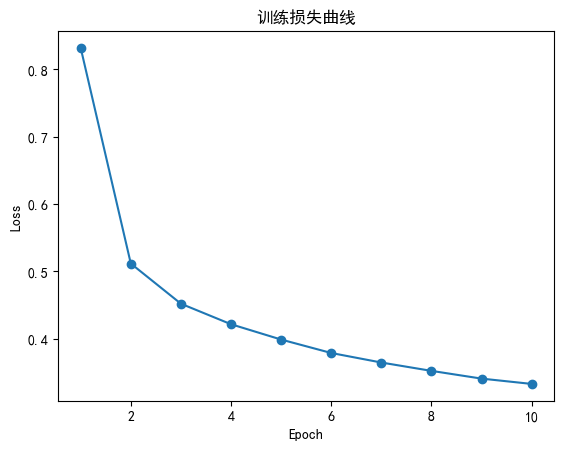

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
torch.manual_seed(42)

# 加载 Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 参数初始化
input_size = 28*28
hidden_size = 256
output_size = 10

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 启用梯度跟踪
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# ReLU
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# Softmax + 交叉熵损失
def cross_entropy_softmax(logits, y):
    # logits: (batch, num_classes), y: (batch,) 索引
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss

# 训练参数
lr = 0.1
epochs = 10

train_losses = []
for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        # 前向
        h = relu(X @ W1 + b1)
        logits = h @ W2 + b2
        loss = cross_entropy_softmax(logits, y)
        
        # 反向（手动清空梯度）
        if W1.grad is not None:
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
        loss.backward()
        
        # 梯度下降更新
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
        
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}, Loss: {avg_loss:.4f}")

# 测试准确率
def compute_accuracy(loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            h = relu(X @ W1 + b1)
            logits = h @ W2 + b2
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

train_acc = compute_accuracy(train_loader)
test_acc = compute_accuracy(test_loader)
print(f"\n训练集准确率: {train_acc*100:.2f}%")
print(f"测试集准确率: {test_acc*100:.2f}%")

# 绘制损失曲线
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失曲线')
plt.show()

3.1 理论计算题

1. 训练误差 vs 泛化误差

- 训练误差：模型在训练集上预测的误差。
- 泛化误差：模型在未见过的测试集上预测的误差。

当训练误差极低但泛化误差很高时，模型处于 **过拟合** 状态。  
缓解方法：降低模型复杂度（减少层数、神经元数）、增加训练数据、数据增强、正则化（L2、Dropout）、早停等。

---

2. K折交叉验证步骤

1. 将训练集随机划分为 K 个大小相等的子集。
2. 对于 k = 1 到 K：
   - 将第 k 个子集作为验证集，其余 K-1 个子集作为训练集。
   - 训练模型并在验证集上评估性能（如准确率）。
3. 计算 K 次评估指标的平均值作为最终性能估计。
4. 最后可用全部数据重新训练模型（用于实际预测）。

=== 无正则化 ===
Epoch  1, Train Loss: 1.1161, Val Loss: 0.7170
Epoch  2, Train Loss: 0.6511, Val Loss: 0.7402
Epoch  3, Train Loss: 0.5623, Val Loss: 0.5801
Epoch  4, Train Loss: 0.5053, Val Loss: 0.8509
Epoch  5, Train Loss: 0.4727, Val Loss: 0.6072
Epoch  6, Train Loss: 0.4438, Val Loss: 0.5215
Epoch  7, Train Loss: 0.4179, Val Loss: 0.5069
Epoch  8, Train Loss: 0.4001, Val Loss: 0.5011
Epoch  9, Train Loss: 0.3863, Val Loss: 0.5624
Epoch 10, Train Loss: 0.3695, Val Loss: 0.5399
Epoch 11, Train Loss: 0.3491, Val Loss: 0.5511
Epoch 12, Train Loss: 0.3369, Val Loss: 0.5008
Epoch 13, Train Loss: 0.3253, Val Loss: 0.5110
Epoch 14, Train Loss: 0.3089, Val Loss: 0.4539
Epoch 15, Train Loss: 0.3003, Val Loss: 0.4904
Epoch 16, Train Loss: 0.2943, Val Loss: 0.4526
Epoch 17, Train Loss: 0.2827, Val Loss: 0.5260
Epoch 18, Train Loss: 0.2722, Val Loss: 0.6477
Epoch 19, Train Loss: 0.2673, Val Loss: 0.5779
Epoch 20, Train Loss: 0.2618, Val Loss: 0.5381

=== 权重衰减 (L2, λ=0.001) ===
Epoch  1, Train Los

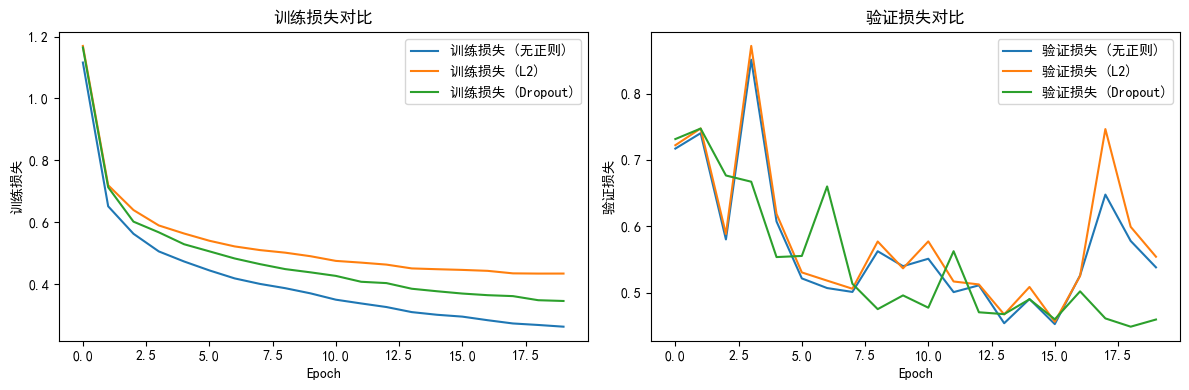

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

# 准备小规模数据以便过拟合
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 只用少量样本训练，制造过拟合
subset_ratio = 0.1
indices = torch.randperm(len(train_set))[:int(len(train_set)*subset_ratio)]
train_subset = torch.utils.data.Subset(train_set, indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

# 定义 Dropout 函数
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1.0 - dropout)

# 定义模型训练函数（可选择 weight_decay 和 dropout）
def train_model(weight_decay=0.0, dropout=0.0, epochs=20, lr=0.1):
    torch.manual_seed(42)
    input_size = 28*28
    hidden_size = 512   # 大容量，易过拟合
    output_size = 10
    
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    W1.requires_grad_(True); b1.requires_grad_(True)
    W2.requires_grad_(True); b2.requires_grad_(True)
    
    def relu(x):
        return torch.maximum(x, torch.tensor(0.0))
    
    def cross_entropy_softmax(logits, y):
        exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
        probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
        return -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        # 训练阶段
        total_loss = 0
        for X, y in train_loader:
            h = relu(X @ W1 + b1)
            if dropout > 0:
                h = dropout_layer(h, dropout, is_training=True)
            logits = h @ W2 + b2
            loss = cross_entropy_softmax(logits, y)
            
            # 添加 L2 正则化
            if weight_decay > 0:
                loss += weight_decay * (torch.norm(W1, p=2)**2 + torch.norm(W2, p=2)**2)
            
            # 反向传播
            if W1.grad is not None:
                W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
            loss.backward()
            with torch.no_grad():
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        
        # 验证阶段（无 dropout）
        val_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                h = relu(X @ W1 + b1)
                if dropout > 0:
                    h = dropout_layer(h, dropout, is_training=False)
                logits = h @ W2 + b2
                loss = cross_entropy_softmax(logits, y)
                val_loss += loss.item()
        val_losses.append(val_loss / len(test_loader))
        print(f"Epoch {epoch+1:2d}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    return train_losses, val_losses

# 对比实验
print("=== 无正则化 ===")
train_none, val_none = train_model(weight_decay=0.0, dropout=0.0, epochs=20)

print("\n=== 权重衰减 (L2, λ=0.001) ===")
train_l2, val_l2 = train_model(weight_decay=0.001, dropout=0.0, epochs=20)

print("\n=== Dropout (p=0.5) ===")
train_drop, val_drop = train_model(weight_decay=0.0, dropout=0.5, epochs=20)

# 绘制对比曲线
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_none, label='训练损失 (无正则)')
plt.plot(train_l2, label='训练损失 (L2)')
plt.plot(train_drop, label='训练损失 (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('训练损失')
plt.legend()
plt.title('训练损失对比')

plt.subplot(1,2,2)
plt.plot(val_none, label='验证损失 (无正则)')
plt.plot(val_l2, label='验证损失 (L2)')
plt.plot(val_drop, label='验证损失 (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('验证损失')
plt.legend()
plt.title('验证损失对比')
plt.tight_layout()
plt.show()

4.1 理论计算题

1. 梯度消失与爆炸的量化分析

深层网络梯度包含多层的雅可比矩阵连乘：  
∏ (∂h^{i+1}/∂h^{i})  

- 若每个矩阵的范数大于1，连乘后趋于无穷 → 梯度爆炸  
- 若每个矩阵的范数小于1，连乘后趋于0 → 梯度消失  

常见原因：  
- 激活函数导数（Sigmoid导数 ≤ 0.25）连乘导致梯度消失  
- 权重初始化太大 → 梯度爆炸；太小 → 梯度消失  

---

2. ReLU缓解梯度消失的原因

ReLU 函数：f(x) = max(0, x)  
导数：  
- 当 x>0 时，导数为 1  
- 当 x<0 时，导数为 0  

在正区间导数恒为1，不会像Sigmoid/tanh那样将梯度缩小，因此深层网络中梯度可以稳定传播，避免消失。  
但要注意负区间（dead ReLU）会阻断梯度，所以常使用 LeakyReLU 等变体。

In [3]:
import torch
import torch.nn as nn
import torch.nn.init as init

def check_grad_norm(model, name):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    print(f"{name} 梯度范数: {total_norm:.6f}")

# 构建20层全连接网络
def build_net(act_fn, init_method=None, std=1.0):
    layers = []
    for i in range(20):
        layers.append(nn.Linear(256, 256))
        if init_method == 'normal':
            init.normal_(layers[-1].weight, mean=0, std=std)
            init.zeros_(layers[-1].bias)
        elif init_method == 'xavier':
            init.xavier_uniform_(layers[-1].weight)
            init.zeros_(layers[-1].bias)
        layers.append(act_fn)
    return nn.Sequential(*layers)

# 模拟梯度消失（Sigmoid + 普通正态 std=1）
model1 = build_net(nn.Sigmoid(), init_method='normal', std=1.0)
x = torch.randn(64, 256)
output = model1(x)
loss = output.mean()
loss.backward()
print("=== Sigmoid + 普通初始化（梯度消失） ===")
check_grad_norm(model1, "整体")

# 模拟梯度爆炸（ReLU + 较大 std=10）
model2 = build_net(nn.ReLU(), init_method='normal', std=10.0)
x = torch.randn(64, 256)
output = model2(x)
loss = output.mean()
loss.backward()
print("\n=== ReLU + 大初始化 std=10（梯度爆炸，可能NaN） ===")
check_grad_norm(model2, "整体")

# 修复：Xavier初始化 + ReLU
model3 = build_net(nn.ReLU(), init_method='xavier')
x = torch.randn(64, 256)
output = model3(x)
loss = output.mean()
loss.backward()
print("\n=== Xavier初始化 + ReLU（稳定区间） ===")
check_grad_norm(model3, "整体")

=== Sigmoid + 普通初始化（梯度消失） ===
整体 梯度范数: 0.603568

=== ReLU + 大初始化 std=10（梯度爆炸，可能NaN） ===
整体 梯度范数: nan

=== Xavier初始化 + ReLU（稳定区间） ===
整体 梯度范数: 0.082996


5.1 理论计算题

### 协变量偏移 (Covariate Shift)
- 定义：输入分布 p(x) 改变，但条件分布 p(y|x) 不变。
- 例子：医疗诊断中，训练数据来自特定年龄段人群，测试时患者年龄分布不同，但病症与症状的关系相同。

### 标签偏移 (Label Shift)
- 定义：标签分布 p(y) 改变，但条件分布 p(x|y) 不变。
- 例子：电商推荐中，训练时用户的点击商品比例某类较多，测试时另一类商品变热门，但商品特征与点击关系不变。

### 区别与联系
- 区别：协变量偏移影响输入特征分布；标签偏移影响输出分布。
- 联系：两者都导致训练与测试分布不一致，模型泛化下降。  
- 修正方法：协变量偏移常用样本加权（重要性采样）；标签偏移常用调整类先验概率。

基线模型测试 MSE: 0.0102
加权模型测试 MSE: 0.0240


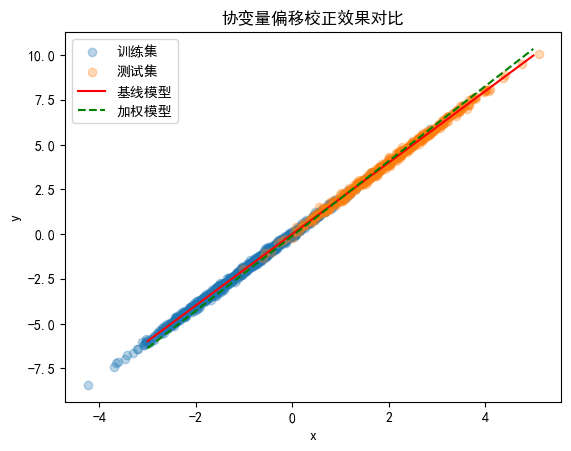

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成数据
np.random.seed(42)
n_train = 1000
n_test = 500
X_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
y_train = 2 * X_train.squeeze() + np.random.normal(0, 0.1, n_train)

X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
y_test = 2 * X_test.squeeze() + np.random.normal(0, 0.1, n_test)

# 2. 基线模型：直接线性回归
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_base = lin_reg.predict(X_test)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"基线模型测试 MSE: {mse_base:.4f}")

# 3. 训练逻辑回归分类器区分训练集和测试集
X_combined = np.vstack([X_train, X_test])
y_combined = np.array([0]*n_train + [1]*n_test)
clf = LogisticRegression()
clf.fit(X_combined, y_combined)
prob_test = clf.predict_proba(X_train)[:, 1]   # P(test|X_train)
prob_train = 1 - prob_test                     # P(train|X_train)

# 计算权重 w = P(test|x) / P(train|x)
weights = prob_test / (prob_train + 1e-8)
weights = weights / np.sum(weights) * n_train   # 归一化到和为 n_train

# 4. 加权线性回归（手动实现）
def weighted_linear_regression(X, y, weights):
    Xw = X * np.sqrt(weights).reshape(-1,1)
    yw = y * np.sqrt(weights)
    return np.linalg.lstsq(Xw, yw, rcond=None)[0]

# 添加截距项
X_train_w = np.hstack([np.ones((n_train,1)), X_train])
w_coef = weighted_linear_regression(X_train_w, y_train, weights)
X_test_w = np.hstack([np.ones((n_test,1)), X_test])
y_pred_weighted = X_test_w @ w_coef
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权模型测试 MSE: {mse_weighted:.4f}")

# 可视化对比
plt.scatter(X_train, y_train, alpha=0.3, label='训练集')
plt.scatter(X_test, y_test, alpha=0.3, label='测试集')
x_line = np.linspace(-3, 5, 100)
plt.plot(x_line, lin_reg.predict(x_line.reshape(-1,1)), 'r-', label='基线模型')
plt.plot(x_line, w_coef[0] + w_coef[1]*x_line, 'g--', label='加权模型')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('协变量偏移校正效果对比')
plt.show()